## [✔] COMPLETO

# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd
import numpy as np
import time
from Bio import Entrez
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_amn_count = pd.read_csv("./data/df_amn_count.csv", index_col="Unnamed: 0")
df_amn_count

,L,G,V,S,Q,E,T,P,K,R,D,A,F,M,N,I,H,W,Y,C
isg15,24.0,18.0,16.0,15.0,12.0,9.0,9.0,8.0,8.0,8.0,7.0,7.0,5.0,4.0,4.0,3.0,3.0,2.0,2.0,1.0
hur,22.0,29.0,22.0,28.0,12.0,15.0,16.0,12.0,18.0,20.0,16.0,23.0,18.0,10.0,23.0,19.0,8.0,2.0,10.0,3.0
ifna,27.0,6.0,10.0,18.0,12.0,14.0,11.0,5.0,11.0,10.0,8.0,11.0,11.0,6.0,4.0,8.0,3.0,2.0,5.0,6.0
tnfa,64.0,45.0,29.0,53.0,39.0,57.0,47.0,56.0,46.0,56.0,30.0,50.0,34.0,20.0,40.0,27.0,30.0,9.0,18.0,40.0
atpsf1a,53.0,51.0,46.0,39.0,25.0,31.0,27.0,18.0,30.0,38.0,29.0,58.0,16.0,12.0,16.0,39.0,7.0,NaN,16.0,2.0


In [4]:
def medidas_tendencia_central(serie):
    """
    Recebe um objeto unidimensional (como uma pandas Series) e 
    retorna um dicionário com a média, mediana e moda.
    """
    # Calculando os valores utilizando os métodos otimizados do pandas
    media = serie.mean()
    mediana = serie.median()
    
    # A moda pode ter mais de um valor (bimodal, multimodal), então convertemos para lista
    moda = serie.mode().tolist()
    
    return {
        "Média": media,
        "Mediana": mediana,
        "Moda(s)": moda
    }

In [5]:
medidas_tendencia_central(df_amn_count["S"])

{'Média': 30.6, 'Mediana': 28.0, 'Moda(s)': [15.0, 18.0, 28.0, 39.0, 53.0]}

In [6]:
serie_terceiro_gene = df_amn_count.iloc[2]

medidas_tendencia_central(serie_terceiro_gene)

{'Média': 9.4, 'Mediana': 9.0, 'Moda(s)': [11.0]}

## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [8]:
def calcular_amplitude(serie):
    """
    Recebe um objeto unidimensional (pandas Series) e 
    retorna a amplitude (valor máximo - valor mínimo).
    """
    return serie.max() - serie.min()

In [13]:
print("Amplitude Isoleucina:")
calcular_amplitude(df_amn_count["I"])

Amplitude Isoleucina:


36.0

In [14]:
serie_ultimo_gene = df_amn_count.iloc[-1]
print("Amplitude do ultimo gene:")
calcular_amplitude(serie_ultimo_gene)

Amplitude do ultimo gene:


56.0

## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [15]:
def calcular_quartis(serie):
    """
    Recebe um objeto unidimensional (pandas Series) e 
    retorna um dicionário com os quartis Q1, Q2 e Q3.
    """
    # O método quantile aceita uma lista com os percentis desejados
    quartis = serie.quantile([0.25, 0.50, 0.75])
    
    return {
        "Q1": quartis[0.25],
        "Q2": quartis[0.50],
        "Q3": quartis[0.75]
    }

In [16]:
print("Quartis da Metionina:")
calcular_quartis(df_amn_count["M"])

Quartis da Metionina:


{'Q1': 6.0, 'Q2': 10.0, 'Q3': 12.0}

In [17]:
print("Quartis do primeiro gene:")
serie_primeiro_gene = df_amn_count.iloc[0]
calcular_quartis(serie_primeiro_gene)

Quartis do primeiro gene:


{'Q1': 3.75, 'Q2': 7.5, 'Q3': 9.75}

## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [18]:
def calcular_iqr(serie):
    """
    Recebe um objeto unidimensional (pandas Series) e 
    retorna o Intervalo Interquartil (Q3 - Q1).
    """
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    return q3 - q1

In [19]:
print("IQR do Ácido Glutâmico ('E')")
calcular_iqr(df_amn_count["E"])

IQR do Ácido Glutâmico ('E')


17.0

In [24]:
print("IQR do penúltimo gene:")
nome_penultimo_gene = df_amn_count.index[-2]
serie_penultimo_gene = df_amn_count.iloc[-2]
calcular_iqr(serie_penultimo_gene)


IQR do penúltimo gene:


21.0

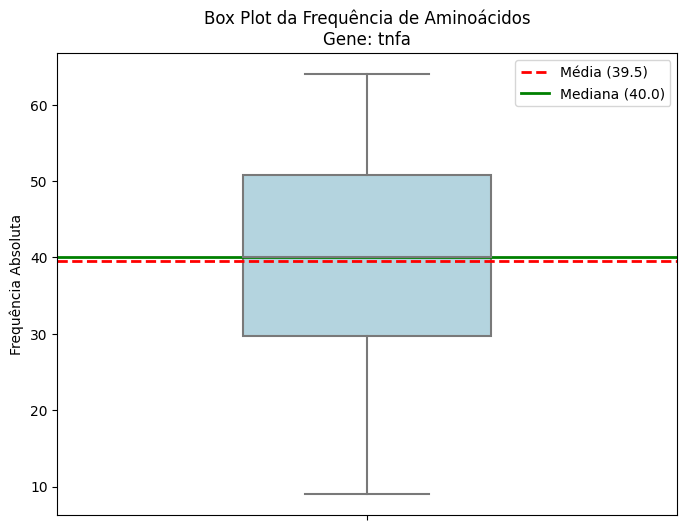

In [26]:
plt.figure(figsize=(8, 6))

sns.boxplot(y=serie_penultimo_gene, color="lightblue", width=0.4)

# Calculando a média e a mediana do penúltimo gene para plotar
media_gene = serie_penultimo_gene.mean()
mediana_gene = serie_penultimo_gene.median()
plt.axhline(media_gene, color='red', linestyle='dashed', linewidth=2, label=f'Média ({media_gene:.1f})')
plt.axhline(mediana_gene, color='green', linestyle='solid', linewidth=2, label=f'Mediana ({mediana_gene:.1f})')


plt.title(f'Box Plot da Frequência de Aminoácidos\nGene: {nome_penultimo_gene}')
plt.ylabel('Frequência Absoluta')
plt.legend()
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [31]:
def calcular_variancia_amostral(serie):
    """
    Recebe um objeto unidimensional (pandas Series) e 
    retorna a variância amostral não viciada.
    """
    # O método .var() do pandas já usa ddof=1 por padrão (não viciada)
    return serie.var(ddof=1)

In [32]:
var_prolina = calcular_variancia_amostral(df_amn_count["P"])
print(f"A variância amostral da Prolina (P) entre os genes é: {var_prolina:.2f}")

A variância amostral da Prolina (P) entre os genes é: 433.20


In [36]:
nome_terceiro_gene = df_amn_count.index[2]
serie_terceiro_gene = df_amn_count.iloc[2]
var_terceiro_gene = calcular_variancia_amostral(serie_terceiro_gene)
print(f"A variância amostral da frequência de aminoácidos no 3º gene ({nome_terceiro_gene}) é: {var_terceiro_gene:.2f}")

A variância amostral da frequência de aminoácidos no 3º gene (ifna) é: 32.88


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [38]:
def calcular_desvio_padrao(serie):
    """
    Recebe um objeto unidimensional (pandas Series) e 
    retorna o desvio padrão amostral.
    """
    # O método .std() do pandas já calcula o desvio padrão amostral por padrão
    return serie.std()

In [39]:
desvio_triptofano = calcular_desvio_padrao(df_amn_count["W"])
print(f"O desvio padrão do Triptofano (W) entre os genes é: {desvio_triptofano:.2f}")

O desvio padrão do Triptofano (W) entre os genes é: 3.50


In [41]:
nome_ultimo_gene = df_amn_count.index[-1]
serie_ultimo_gene = df_amn_count.iloc[-1]
desvio_ultimo_gene = calcular_desvio_padrao(serie_ultimo_gene)
print(f"O desvio padrão da frequência de aminoácidos no último gene ({nome_ultimo_gene}) é: {desvio_ultimo_gene:.2f}")

O desvio padrão da frequência de aminoácidos no último gene (atpsf1a) é: 16.03


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [43]:
def calcular_coeficiente_variacao(serie):
    """
    Recebe um objeto unidimensional (pandas Series) e 
    retorna o Coeficiente de Variação (CV) em porcentagem.
    """
    media = serie.mean()
    desvio_padrao = serie.std(ddof=1)
    
    # Prevenindo divisão por zero caso a média seja 0
    if media == 0:
        return 0
        
    cv = (desvio_padrao / media) * 100
    return cv

In [44]:
cv_leucina = calcular_coeficiente_variacao(df_amn_count["L"])
print(f"O Coeficiente de Variação (CV) da Leucina (L) entre os genes é: {cv_leucina:.2f}%")

O Coeficiente de Variação (CV) da Leucina (L) entre os genes é: 50.52%


In [45]:
nome_gene_index_1 = df_amn_count.index[1]
serie_gene_index_1 = df_amn_count.iloc[1]
cv_gene_index_1 = calcular_coeficiente_variacao(serie_gene_index_1)
print(f"O Coeficiente de Variação (CV) da frequência de aminoácidos no gene '{nome_gene_index_1}' (index 1) é: {cv_gene_index_1:.2f}%")

O Coeficiente de Variação (CV) da frequência de aminoácidos no gene 'hur' (index 1) é: 45.57%


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [46]:
def calcular_medidas_resumo(serie):
    """
    Recebe um objeto unidimensional (pandas Series) e 
    retorna um dicionário com todas as principais medidas resumo.
    """
    # 1. Medidas de Tendência Central
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode().tolist()
    
    # 2. Medidas de Posição (Quartis)
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    
    # 3. Medidas de Dispersão
    amplitude = serie.max() - serie.min()
    iqr = q3 - q1
    variancia = serie.var(ddof=1)
    desvio_padrao = serie.std(ddof=1)
    
    # Prevenção para divisão por zero no CV
    cv = (desvio_padrao / media * 100) if media != 0 else 0
    
    # 4. Montando o dicionário final com chaves claras
    medidas = {
        "Média": media,
        "Mediana": mediana,
        "Moda(s)": moda,
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "Amplitude": amplitude,
        "Intervalo Interquartil (IQR)": iqr,
        "Variância Amostral": variancia,
        "Desvio Padrão": desvio_padrao,
        "Coeficiente de Variação (%)": cv
    }
    
    return medidas

In [48]:
calcular_medidas_resumo(df_amn_count["A"])

{'Média': 29.8,
 'Mediana': 23.0,
 'Moda(s)': [7.0, 11.0, 23.0, 50.0, 58.0],
 'Q1 (25%)': 11.0,
 'Q3 (75%)': 50.0,
 'Amplitude': 51.0,
 'Intervalo Interquartil (IQR)': 39.0,
 'Variância Amostral': 530.7,
 'Desvio Padrão': 23.03692687838376,
 'Coeficiente de Variação (%)': 77.30512375296563}

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [49]:
def maior_cv_genes(df):
    """
    Recebe um DataFrame onde as linhas são os genes e calcula o CV para cada um.
    Retorna o gene com o maior CV, o valor desse CV e a lista completa para conferência.
    """
    # Calcula o CV (Desvio Padrão / Média * 100) para cada linha (axis=1)
    cv_genes = df.apply(lambda linha: (linha.std(ddof=1) / linha.mean()) * 100 if linha.mean() != 0 else 0, axis=1)
    
    # Identifica o gene e o valor máximo
    gene_max = cv_genes.idxmax()
    cv_max = cv_genes.max()
    
    return gene_max, cv_max, cv_genes

In [52]:
gene_maior_cv, valor_maior_cv, todos_cvs = maior_cv_genes(df_amn_count)
print("Coeficientes de Variação (CV) por Gene")
print(todos_cvs)
print(f"\nO gene com o MAIOR Coeficiente de Variação é o '{gene_maior_cv}' com {valor_maior_cv:.2f}%.")

Coeficientes de Variação (CV) por Gene
isg15      73.559828
hur        45.567759
ifna       61.005060
tnfa       37.293468
atpsf1a    55.078886
dtype: float64

O gene com o MAIOR Coeficiente de Variação é o 'isg15' com 73.56%.


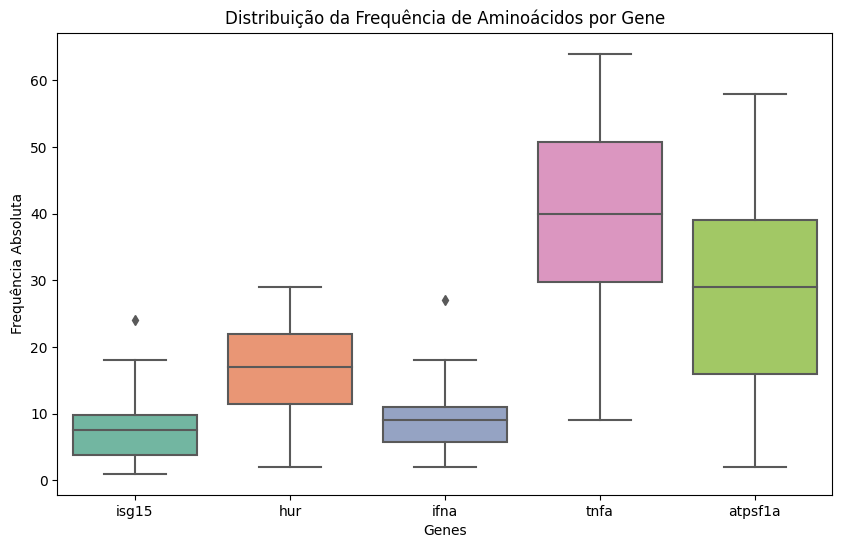

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_amn_count.T, palette="Set2")

plt.title('Distribuição da Frequência de Aminoácidos por Gene')
plt.xlabel('Genes')
plt.ylabel('Frequência Absoluta')

plt.show()

R.: Sim, os dados concordam. O aparente conflito entre o gráfico e os cálculos ocorre devido à diferença entre dispersão absoluta e dispersão relativa. 
<br>O Boxplot mostra a dispersão absoluta: O tamanho da caixa e a extensão das linhas no gráfico refletem a variação em números brutos (Amplitude e Intervalo Interquartil). Genes que expressam uma quantidade enorme de aminoácidos no total (como o tnfa) naturalmente terão uma variação maior em valores absolutos. Por isso, a caixa deles no gráfico é muito mais larga e esticada.
<br>
<br>O Coeficiente de Variação mede a variação relativa de forma proporcional ao tamanho do próprio grupo (Desvio Padrão dividido pela Média). O gene isg15 é pequeno e possui uma média de aminoácidos muito baixa. Logo, o seu desvio padrão (que é em torno de 6) representa uma flutuação gigantesca em relação à sua média (que é em torno de 8). Isso significa que a variação equivale a mais de 70% do seu tamanho médio.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [54]:
def maior_cv_aminoacidos(df):
    """
    Recebe um DataFrame onde as colunas são os aminoácidos e calcula o CV para cada um.
    Retorna o aminoácido com o maior CV, o valor desse CV e a série completa com todos os CVs.
    """
    # Calcula o CV (Desvio Padrão / Média * 100) para cada coluna (axis=0)
    cv_aa = df.apply(lambda coluna: (coluna.std(ddof=1) / coluna.mean()) * 100 if coluna.mean() != 0 else 0, axis=0)
    
    # Identifica o aminoácido e o valor máximo
    aa_max = cv_aa.idxmax()
    cv_max = cv_aa.max()
    
    return aa_max, cv_max, cv_aa

In [57]:
aa_maior_cv, valor_maior_cv, todos_cvs_aa = maior_cv_aminoacidos(df_amn_count)
print("Coeficientes de Variação (CV) dos Aminoácidos")

print(todos_cvs_aa.sort_values(ascending=False).head())

print(f"\nO aminoácido com o MAIOR Coeficiente de Variação entre os genes é '{aa_maior_cv}' com {valor_maior_cv:.2f}%.")

Coeficientes de Variação (CV) dos Aminoácidos
C    160.118530
H    110.788652
P    105.118471
W     93.333333
N     86.360017
dtype: float64

O aminoácido com o MAIOR Coeficiente de Variação entre os genes é 'C' com 160.12%.


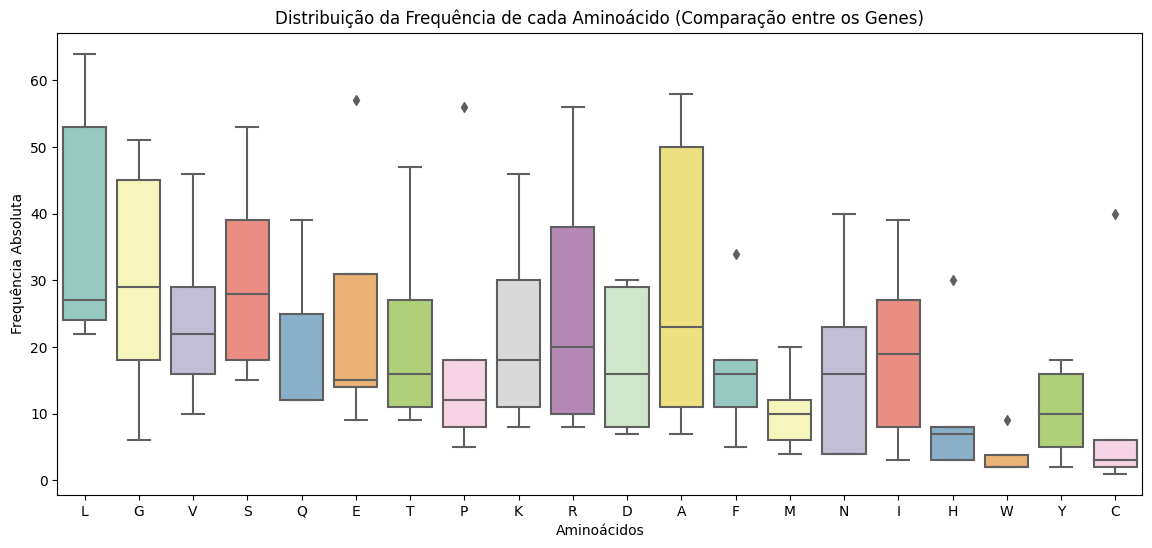

In [58]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df_amn_count, palette="Set3")

plt.title('Distribuição da Frequência de cada Aminoácido (Comparação entre os Genes)')
plt.xlabel('Aminoácidos')
plt.ylabel('Frequência Absoluta')
plt.show()

R.: Sim, os dados concordam. O aparente conflito ocorre porque o Boxplot e o Coeficiente de Variação (CV) estão mostrando tipos diferentes de dispersão:
<br>O Boxplot mostra a dispersão absoluta: O tamanho da caixa e a extensão do gráfico refletem a variação em números brutos. Genes com uma grande quantidade de aminoácidos expressos (como o tnfa ou atpsf1a) naturalmente apresentam maiores variações na contagem, resultando em caixas mais largas no gráfico.
<br>
<br>O CV mostra a dispersão relativa, ele mede o quanto os dados variam em proporção à sua própria média (Desvio Padrão dividido pela Média). O gene isg15 possui o maior CV porque ele é um gene pequeno (com média baixa). Assim, mesmo que sua variação absoluta seja menor que a do tnfa, essa variação representa uma flutuação gigantesca proporcionalmente ao seu tamanho.